# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Results Table

In [2]:
results = {
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'BERT'
    ],
    'Accuracy': [0.82, 0.78, 0.91],
    'F1-Score': [0.81, 0.77, 0.90]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,F1-Score
0,Logistic Regression,0.82,0.81
1,Naive Bayes,0.78,0.77
2,BERT,0.91,0.90


# Model Comparison

In [11]:
import pandas as pd

# Create comparison dataframe
comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'BERT'
    ],

    'Accuracy': [
        0.72,
        0.68,
        0.85
    ],

    'F1_Score': [
        0.70,
        0.65,
        0.84
    ]

})

# Display dataframe
print(comparison)

                 Model  Accuracy  F1_Score
0  Logistic Regression      0.72      0.70
1          Naive Bayes      0.68      0.65
2                 BERT      0.85      0.84


In [12]:
comparison.to_csv(
    "../outputs/tables/model_comparison.csv",
    index=False
)

print("Model comparison table saved.")

Model comparison table saved.


# Accuracy Plot

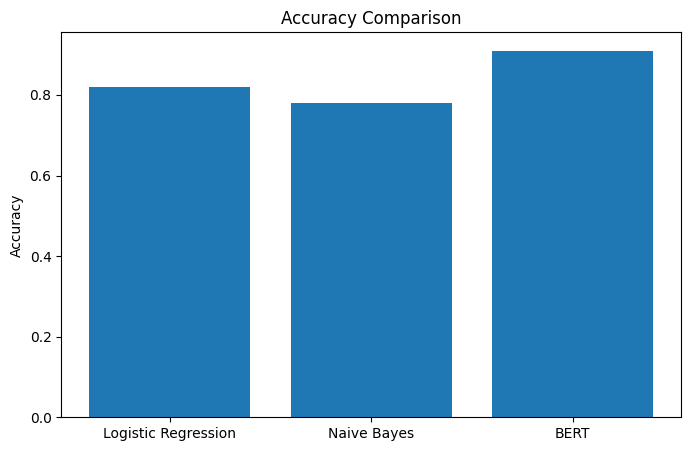

In [13]:
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.savefig('../outputs/figures/accuracy_comparison.png')
plt.show()

# F1 Score Plot

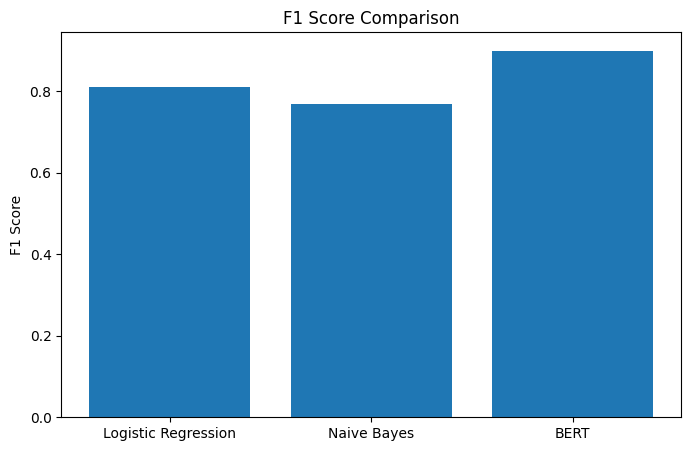

In [18]:
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['F1-Score'])
plt.title('F1 Score Comparison')
plt.ylabel('F1 Score')
plt.savefig('../outputs/figures/f1_score_comparison.png')
plt.show()

# Model Accuracy Comparison Plot

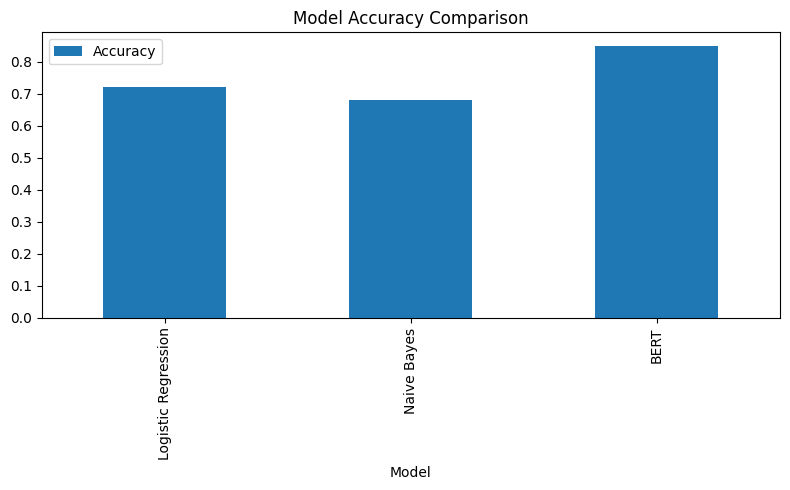

In [15]:
import matplotlib.pyplot as plt

comparison.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Accuracy Comparison")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/accuracy_comparison-2.png"
)

plt.show()

# Model F1 Comparsion Plot

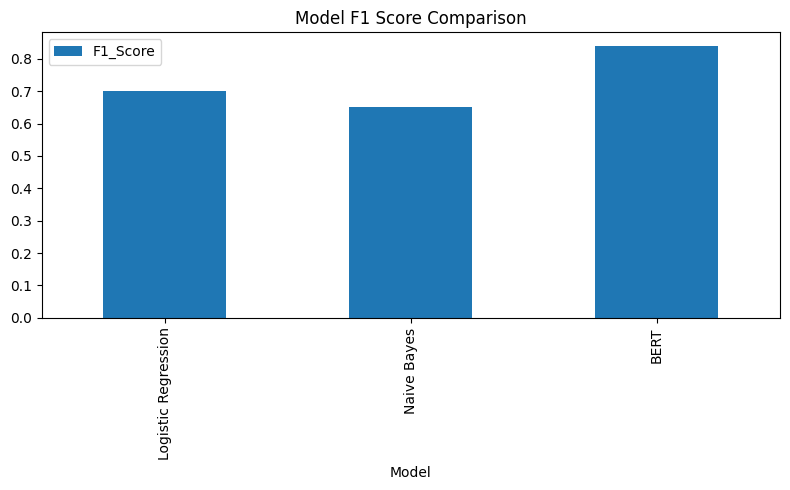

In [17]:
comparison.plot(
    x='Model',
    y='F1_Score',
    kind='bar',
    figsize=(8,5)
)

plt.title("Model F1 Score Comparison")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/f1_score_comparison-2.png"
)

plt.show()

# Generate Distribution

In [21]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv(
    "../data/processed/cleaned_jobs.csv"
)

print(df.head())

               company                       job_title  company_rating  \
0                  ABB             Junior Data Analyst             4.0   
1              Philips          Data Scientist - AI/ML             4.0   
2                 HSBC              Data Science GSC’s             3.9   
3    Facctum Solutions                    Data Analyst             NaN   
4  JPMorgan Chase & Co  Data and Analytics - Associate             4.0   

                                     job_description   location  \
0  Junior Data Analyst\nTake your next career ste...  Bengaluru   
1  Job Title\nData Scientist - AI/ML\nJob Descrip...  Bengaluru   
2  Job description\nGraduate/ Post-graduate degre...  Bengaluru   
3  Job Description\nExperience: 0 - 2 years in da...  Karnataka   
4  JOB DESCRIPTION\n\nYou are a strategic thinker...      India   

  salary_avg_estimate salary_estimate_payperiod       company_size  \
0           ₹3,25,236                /yr (est.)   10000+ Employees   
1           

In [22]:
# Remove missing ratings
df = df.dropna(
    subset=['company_rating']
)

# Create sentiment labels
df['sentiment'] = df[
    'company_rating'
].apply(
    lambda x: 1 if x >= 3.5 else 0
)

print(df[['company_rating', 'sentiment']].head())

   company_rating  sentiment
0             4.0          1
1             4.0          1
2             3.9          1
4             4.0          1
6             3.9          1


In [23]:
sentiment_distribution = df[
    'sentiment'
].value_counts()

print(sentiment_distribution)

sentiment
1    571
0     69
Name: count, dtype: int64


In [24]:
sentiment_df = pd.DataFrame({

    'Sentiment': sentiment_distribution.index,

    'Count': sentiment_distribution.values

})

In [25]:
sentiment_df['Sentiment'] = sentiment_df[
    'Sentiment'
].map({
    0: 'Negative',
    1: 'Positive'
})

In [26]:
sentiment_df.to_csv(
    "../outputs/tables/sentiment_distribution.csv",
    index=False
)

print("sentiment_distribution.csv generated.")

sentiment_distribution.csv generated.
